---

<center>

# **Tarea 01**

**Realizado por:**

Samuel Huertas Rojas

</center>

---

In [1]:
#  --- Librerias a importar ---
# %load_ext autoreload
# %autoreload 2
# import sys

# sys.path.append("../Tarea_01")

import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

from matplotlib.animation import FuncAnimation, PillowWriter


In [2]:
# Algoritmos para la factorización de matrices y sustitución progresiva y regresiva
# ------ Factorización LU ------
def matrix_factorization_nxn(
    diagonal: np.array,                     # Vector que contiene los coeficientes de la matriz (diagonal)
    diagonal_superior: np.array,            # Vector que contiene los coeficientes de la matriz (diagonal superior)
    diagonal_inferior: np.array,            # Vector que contiene los coeficientes de la matriz (diagonal inferior)
):
    """
    Función para realizar la factorización de una matriz tridiagonal A = L*U
    donde L es una matriz triangular inferior con 1's en la diagonal principal y
    U es una matriz triangular superior.
    Parámetros:
    diagonal : np.array
        Vector que contiene los coeficientes de la matriz (diagonal)
    diagonal_superior : np.array
        Vector que contiene los coeficientes de la matriz (diagonal superior)
    diagonal_inferior : np.array
        Vector que contiene los coeficientes de la matriz (diagonal inferior)
    Retorna:
    l_diag : np.array
        Vector que contiene los coeficientes de la matriz L (diagoanl)
    l_diag_inf : np.array
        Vector que contiene los coeficientes de la matriz L (diagonal inferior)
    u_diag_sup : np.array
        Vector que contiene los coeficientes de la matriz U (diagonal)
    """
    l_diag = np.zeros(len(diagonal))
    l_diag_inf = np.zeros(len(diagonal_inferior))
    u_diag_sup = np.zeros(len(diagonal_superior))

    l_diag[0] = diagonal[0]
    l_diag_inf = diagonal_inferior.copy()
    for i in range(0, len(diagonal_superior)):
        u_diag_sup[i] = diagonal_superior[i] / l_diag[i]
        l_diag[i + 1] = diagonal[i + 1] - l_diag_inf[i] * u_diag_sup[i]

    return l_diag, l_diag_inf, u_diag_sup


# ------ Algoritmos para la sustitución progresiva y regresiva ------
# === Sustirución Regresiva ===
# Solución del sistema Ux = z
def sustitucion_regresiva(
    u_diagonal_superior: np.array,                  # Vector que contiene los coeficientes de la matriz U (diagonal superior)
    termino_independiente: np.array,                # Vector que contiene los términos independientes
):
    x = np.zeros(len(termino_independiente))
    x[-1] = termino_independiente[-1]
    for i in range(len(termino_independiente) - 2, -1, -1):  # de n-2 hasta 0
        x[i] = termino_independiente[i] - u_diagonal_superior[i] * x[i + 1]

    return x

# === Sustitución Progresiva ===
# Solución del sistema Lz = b 
def sustitucion_progresiva(
    l_diagonal: np.array,                       # Vector que contiene los coeficientes de la matriz L (diagonal)
    l_diagonal_inferior: np.array,              # Vector que contiene los coeficientes de la matriz L (diagonal inferior)
    termino_independiente: np.array,            # Vector que contiene los términos independientes
):
    z = np.zeros(len(termino_independiente))
    z[0] = termino_independiente[0] / l_diagonal[0]
    for i in range(1, len(termino_independiente)):
        z[i] = (termino_independiente[i] - l_diagonal_inferior[i - 1] * z[i - 1]) / l_diagonal[i]

    return z

In [3]:
class Esquema(ABC):
    def __init__(self):
        pass

    @abstractmethod
    def calcular_esquema(self):
        pass

In [4]:
# --- Función para animar y guardar la animación ---
def animar_esquema(
        N, 
        condicion_inicial,
        esquema: Esquema, 
        filename: str,
):
    """
    Genera y guarda una animación de la evolución de V usando esquema_prog_prog.

    Parámetros
    ----------
    N : int
        Número de pasos de tiempo.
    diag : array
        Diagonal principal.
    diag_sup : array
        Diagonal superior.
    F : array
        Término fuente.
    condicion_inicial : array
        Condición inicial.
    filename : str
        Nombre del archivo de salida (GIF).
    """
    # Matriz para guardar los resultados
    V = esquema.calcular_esquema()

    # --- Animación ---
    fig, ax = plt.subplots()
    (line,) = ax.plot(V[0, :], lw=2)
    ax.set_ylim(np.min(V), np.max(V) + 0.5)
    ax.set_xlim(0, len(condicion_inicial) - 1)
    ax.set_title(filename)
    ax.set_xlabel("Espacio")
    ax.set_ylabel("Amplitud")
    ax.grid(True)

    def update(frame):
        line.set_ydata(V[frame, :])
        return (line,)

    ani = FuncAnimation(fig, update, frames=range(N + 1), interval=100, blit=True)

    # Guardar como GIF
    gif_name = filename + ".gif"
    ani.save(gif_name, writer=PillowWriter(fps=10))
    plt.close(fig)
    print(f"✅ Animación guardada en {filename}")

    return ani

# Ejercicio 1.

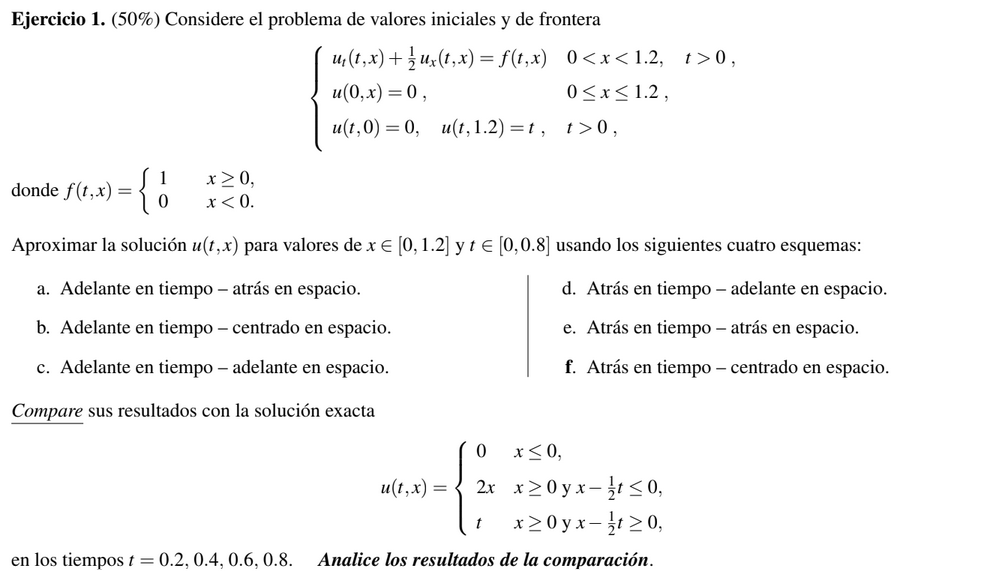

In [5]:
# Variables de la parte espacial
a = 0                                   # Limite inferior del intervalo a evaluar
b = 1.2                                 # Limite superior del intervalo a evaluar
M = 10                                 # Número de divisiones de la parte espacial

h = (b - a) / M                         # Tamaño de paso: h = (b-a)/M

# Variables de la parte temporal
T = 0.8                                 # Limite superior del intervalo temporal
N  = 200                                  # Número de divisones de la parte temporal

k = T / N                               # Tamaño de paso: k = T/N

variable_temporal = np.arange(0, T + k, k)
variable_espacial = np.arange(a, b, h)

t_comparación = [0.2, 0.4, 0.6, 0.8]    # Valores de tiempo para realizar comparación

alpha = 1/2                             # Constante que acompaña a la derivada espacial

print(f"Valores a evaluar temporalmente: {variable_temporal}")
print(f"Valores de las constantes h: {h} y k:{k}, k/h: {k/h}")

Valores a evaluar temporalmente: [0.    0.004 0.008 0.012 0.016 0.02  0.024 0.028 0.032 0.036 0.04  0.044
 0.048 0.052 0.056 0.06  0.064 0.068 0.072 0.076 0.08  0.084 0.088 0.092
 0.096 0.1   0.104 0.108 0.112 0.116 0.12  0.124 0.128 0.132 0.136 0.14
 0.144 0.148 0.152 0.156 0.16  0.164 0.168 0.172 0.176 0.18  0.184 0.188
 0.192 0.196 0.2   0.204 0.208 0.212 0.216 0.22  0.224 0.228 0.232 0.236
 0.24  0.244 0.248 0.252 0.256 0.26  0.264 0.268 0.272 0.276 0.28  0.284
 0.288 0.292 0.296 0.3   0.304 0.308 0.312 0.316 0.32  0.324 0.328 0.332
 0.336 0.34  0.344 0.348 0.352 0.356 0.36  0.364 0.368 0.372 0.376 0.38
 0.384 0.388 0.392 0.396 0.4   0.404 0.408 0.412 0.416 0.42  0.424 0.428
 0.432 0.436 0.44  0.444 0.448 0.452 0.456 0.46  0.464 0.468 0.472 0.476
 0.48  0.484 0.488 0.492 0.496 0.5   0.504 0.508 0.512 0.516 0.52  0.524
 0.528 0.532 0.536 0.54  0.544 0.548 0.552 0.556 0.56  0.564 0.568 0.572
 0.576 0.58  0.584 0.588 0.592 0.596 0.6   0.604 0.608 0.612 0.616 0.62
 0.624 0.628 0.632 0.

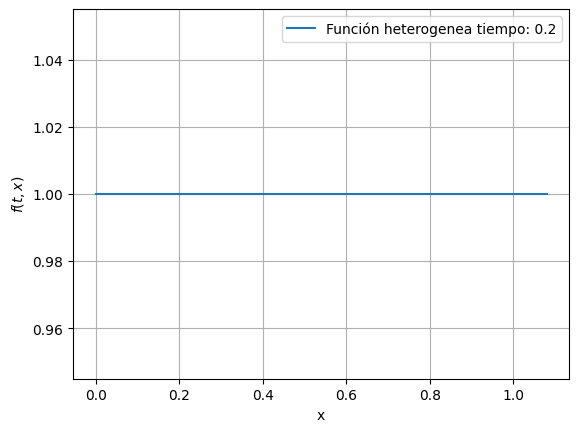

In [6]:
# Función f(t,x)
def funcion_heterogenea(
        x,
        t,
):
    """
    Función heterogenea de la Ecuación Diferencial Parcial.
    t : float o np.ndarray
    x : float o np.ndarray
    """
    t = np.array(t)
    x = np.array(x)
    
    return np.piecewise(
        x,
        [x < 0,
         (x >= 0)],
        [0, 1]
    )    

f = funcion_heterogenea(variable_espacial, 0.2)
plt.plot(variable_espacial, f, label=f"Función heterogenea tiempo: {0.2}")
plt.xlabel("x")
plt.ylabel("$f(t, x)$")
plt.grid(True)
plt.legend()

In [7]:
# --- Condición inicial u(0,x) = 0 ---
def condicion_inicial(
        x,
        t,
):
    return np.zeros(len(x))

## Solución exacta

In [8]:
def solucion_exacta(
       x,                   # Variable espacial
       t,                   # Variable temporal
):
    """
    Solución excata al PVI dado anterior mente.
    t : float o np.ndarray
    x : float o np.ndarray
    """
    t = np.array(t)
    x = np.array(x)
    
    return np.piecewise(
        x,
        [x <= 0,
         (x >= 0) & (x - 0.5*t <= 0),
         (x >= 0) & (x - 0.5*t >= 0)],
        [0, lambda x: 2*x, lambda x: t]
    )

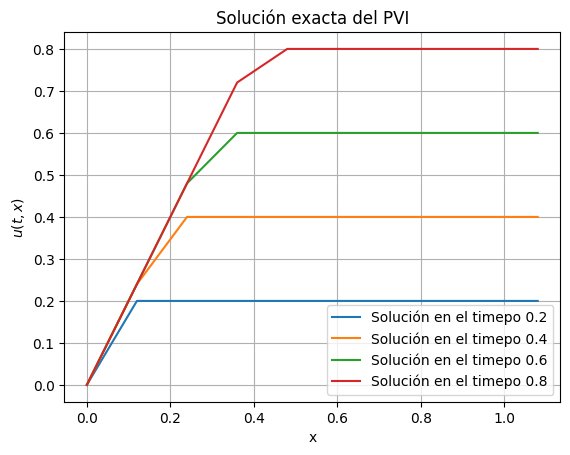

In [9]:
# Graficar la solución exacta del PVI
for t in t_comparación:
    u = solucion_exacta(variable_espacial, t)
    plt.plot(variable_espacial, u, label=f"Solución en el timepo {t}")

plt.title("Solución exacta del PVI")
plt.xlabel("x")
plt.ylabel("$u(t, x)$")
plt.grid(True)
plt.legend()
    

## b. Adelante en tiempo - cenrado en espacio

El esquema dado para adelante en tiempo - centrado en espacio está dado por:

$ \frac{V_{m}^{n+1} - V_{m}^{n}}{k} + a \frac{V_{m+1}^{n} - V_{m-1}^{n}}{2h} = f_{m}^{n}$

Despejando para el timepo $t_{n+1}$:

$V_{m}^{n+1} = V_{m}^{n} + \frac{ak}{2h} (V_{m-1}^{n} - V_{m+1}^{n}) + kf_{m}^{n}$ con: $m=1,..., M-1$ y $n=0,..,N-1$

Se puede evidenciar que este esquema es un esquema explicita y de a un paso 

Resolviendo el sistema lineal de ecuaciones, nos damos cuenta que se puede resolver como una sistema matricial: <br>
<center>

$V^{n+1} = AV^{n} + \tilde{\hat{F}}$

</center>

Lo que nos da la matriz $A$ como:

<center>

$
A = \begin{bmatrix}
1              & -\frac{ak}{2h}   & 0               & 0                & 0               & 0              \\
\frac{ak}{2h}  & 1               & -\frac{ak}{2h}   & 0                & 0               & \vdots         \\
0              & \frac{ak}{2h}   & 1               & -\frac{ak}{2h}    & 0               & \vdots         \\
0              & 0               & \frac{ak}{2h}   & \ddots           & \ddots          & 0              \\
\vdots         & \vdots          & 0               & \ddots           & \ddots          & -\frac{ak}{2h}  \\
0              & 0               & 0               & 0                & \frac{ak}{2h}   & 1              \\
\end{bmatrix}
$

</center>



<center>

$
\tilde{\hat{F}} = \begin{bmatrix}
kf_m^n + \frac{ak}{2h}u(t,0) \\
kf_m^n \\
kf_m^n \\
kf_m^n \\
\vdots \\
kf_m^n - \frac{ak}{2h}u(t,1.2)
\end{bmatrix}
$

</center>

Para la construcción de la matriz A solo es necesario el almacenamiento de la diagonal y las diagonales superior e inferior, ya que el resto de los valores son 0, los cuales no brindan información.

### Estabilidad

Analizando la estabilidad del sistema, tenemos que:

$V_{m}^{n+1} = V_{m}^{n} + \frac{a\lambda}{2}(V_{m-1}^{n} - V_{m+1}^{n}) $

$\Longrightarrow  |V_{m}^{n+1}|^2 = |V_{m}^{n} + \frac{a\lambda}{2}(V_{m-1}^{n} - V_{m+1}^{n})|^2 $ 

$\Longrightarrow  |V_{m}^{n+1}|^2 \leq |V_{m}^{n}|^2 + \frac{|a\lambda|^2}{2}|(V_{m-1}^{n} - V_{m+1}^{n})|^2 $ 

$ = |V_{m}^{n}|^2 + \frac{|a\lambda|^2}{2}(|V_{m-1}^{n}| - |V_{m+1}^{n}|)^2 $ 

$ = |V_{m}^{n}|^2 + \frac{|a\lambda|^2}{2}(|V_{m-1}^{n}|^2 - 2|V_{m+1}^{n}||V_{m-1}^{n}|  + |V_{m+1}^{n}|^2) $ 

$ = |V_{m}^{n}|^2 + \frac{|a\lambda|^2}{2}|V_{m-1}^{n}|^2 - |a\lambda|^2|V_{m+1}^{n}||V_{m-1}^{n}|  + \frac{|a\lambda|^2}{2}|V_{m+1}^{n}|^2 $ 


$ \leq |V_{m}^{n}|^2 + \frac{|a\lambda|^2}{2}|V_{m-1}^{n}|^2 - |a\lambda|^2(|V_{m+1}^{n}|^2 + |V_{m-1}^{n}|^2)  + \frac{|a\lambda|^2}{2}|V_{m+1}^{n}|^2 $ 


$ = |V_{m}^{n}|^2 - \frac{|a\lambda|^2}{2}|V_{m-1}^{n}|^2 - \frac{|a\lambda|^2}{2}|V_{m+1}^{n}|^2 $ 




Con lo que 


$\sum_{m=-\infty}^{\infty}  |V_{m}^{n+1}|^2 \leq \sum_{m=-\infty}^{\infty} |V_{m}^{n}|^2 - \frac{|a\lambda|^2}{2}\sum_{m=-\infty}^{\infty} (|V_{m-1}^{n}|^2 + |V_{m+1}^{n}|^2)$

$=  \sum_{m=-\infty}^{\infty} |V_{m}^{n}|^2 - \frac{|a\lambda|^2}{2}\sum_{m=-\infty}^{\infty} (2|V_{m}^{n}|^2)$

$\Longrightarrow  \sum_{m=-\infty}^{\infty}  |V_{m}^{n+1}|^2 \leq (1-|a\lambda|^2) \sum_{m=-\infty}^{\infty} |V_{m}^{n}|^2$

$\Longrightarrow  \sum_{m=-\infty}^{\infty}  |V_{m}^{n+1}|^2 \leq (1-|a\lambda|^2)^{n+1} \sum_{m=-\infty}^{\infty} |V_{m}^{0}|^2$

Se dede de cumplir que $1 - (a\lambda)^2 \leq 1$ cuando $n \longrightarrow \infty$ para que no "explote", por lo que se debe de cumplir que: 

$1 - (a\lambda)^2 \leq 1 \Longrightarrow  (a\lambda)^2 \geq 0$

Como $(a\lambda)^2$ siempre va a ser un número positivo, el esquema siempre va a ser estable.

In [10]:
cons_DC = (alpha * k) / (2 * h)
cond_iniciales = condicion_inicial(x=variable_espacial, t=variable_temporal[0])

In [11]:
class EsquemaAdelanteCentrado(Esquema):
    def __init__(
            self,
            valor_M,
            valor_N,
            valor_k,
            constante_matriz,
    ):
        self.valor_M = valor_M
        self.valor_N = valor_N
        self.valor_k = valor_k
        self.constante_matriz = constante_matriz
        
    def calcular_esquema(self):
        diag = np.ones(self.valor_M)
        diag_inf = np.zeros(self.valor_M - 1) + self.constante_matriz
        diag_sup = np.zeros(self.valor_M - 1) - self.constante_matriz

        # Factorización de la matriz
        diag_L, diag_inf_L, diag_sup_U = matrix_factorization_nxn(
            diagonal=diag, 
            diagonal_superior=diag_sup,
            diagonal_inferior=diag_inf
        )

        V = np.zeros((self.valor_N + 1,self.valor_M))

        # Condiciones iniciales 
        cond_iniciales = condicion_inicial(x=variable_espacial, t=variable_temporal[0])
        V[0,:] = cond_iniciales

        for i in range(1, N+1):
            # Construcción del vector F
            F = funcion_heterogenea(
                x=variable_espacial,
                t=variable_temporal[i]
            ) * self.valor_k

            # Definicione de las condiciones de frontera (inferior y superior)
            condicion_frontera_inf = 0
            condicion_frontera_sup = variable_temporal[i]
            
            # Ciclo for para entontrar el valor de V en el tiempo i y en todos los puntos del espacio
            for j in range(1, self.valor_M):
                # Calculo del valor de V teniendo en cuenta la condición de frontera inferior
                if j == 1:
                    V[i,j] = V[i-1,j] + self.constante_matriz * (condicion_frontera_inf - V[i-1, j+1]) + F[j]
                # Calculo del valor de V teniendo en cuenta la condición de frontera superior
                elif j == self.valor_M-1:
                    V[i,j] = V[i-1,j] + self.constante_matriz * (V[i-1, j-1] - condicion_frontera_sup) + F[j]
                # Calculo de V en los puntos intermedios
                else:
                    V[i,j] = V[i-1,j] + self.constante_matriz * (V[i-1, j-1] - V[i-1, j+1]) + F[j]

        return V

In [12]:
esquema_DC = EsquemaAdelanteCentrado(
    valor_M= M,
    valor_N= N,
    valor_k= k,
    constante_matriz= cons_DC,
)

animar_esquema(
    N= N,
    esquema= esquema_DC,
    condicion_inicial= cond_iniciales,
    filename="Esquema adelante tiempo - centrado espacio"
)

✅ Animación guardada en Esquema adelante tiempo - centrado espacio


### Comparación con la solución exacta

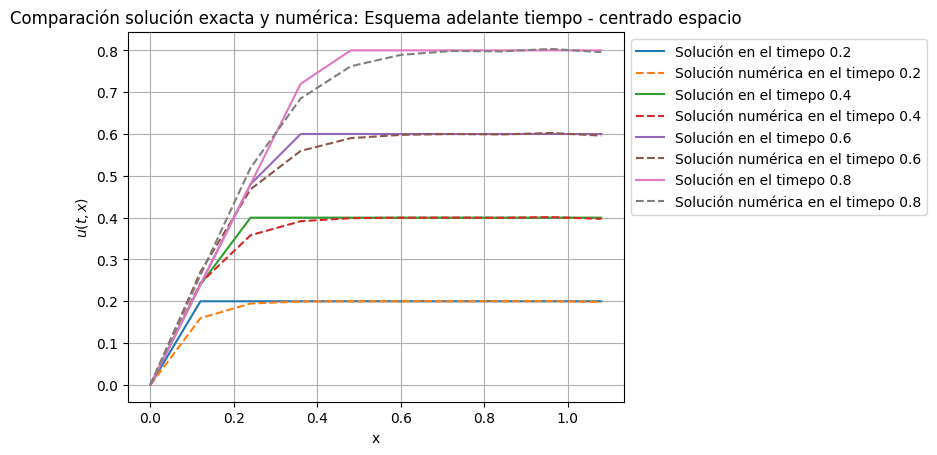

In [13]:
solucion_DF = esquema_DC.calcular_esquema()

indices = [np.where(variable_temporal == t)[0][0] for t in t_comparación]


for pos, t in enumerate(t_comparación):
    u = solucion_exacta(variable_espacial, t)
    plt.plot(variable_espacial, u, label=f"Solución en el timepo {t}")
    plt.plot(variable_espacial, solucion_DF[indices[pos],:], label=f"Solución numérica en el timepo {t}", linestyle='dashed')

plt.title("Comparación solución exacta y numérica: Esquema adelante tiempo - centrado espacio")
plt.xlabel("x")
plt.ylabel("$u(t, x)$")
plt.grid(True)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

Es importante notar que los esquemas implicitos (e. y f.) son estables para cualquier valor de $a$ y $\lambda$

## e. Atrás en tiempo - atrás en espacio

$ \frac{V_{m}^{n} - V_{m}^{n-1}}{k} + a \frac{V_{m}^{n} - V_{m-1}^{n}}{h} = f_{m}^{n}$

Despejando el tiempo nuevo $t_{n}$ en terminos del viejo tiempo $t_{n-1}$, se obtiene: 

$ (1 + \frac{ka}{h}) V_{m}^{n} - \frac{ka}{h} V_{m-1}^{n}  = kf_{m}^{n} + V_{m}^{n-1}$ con: $m=1,...,M-1$ y $n=1,..,N$

Resolviendo el sistema lineal de ecuaciones, nos damos cuenta que se puede resolver como una sistema matricial: <br>
<center>

$AV^{n} = V^{n-1} + \tilde{F}$

</center>

Lo que nos da la matriz $A$ como:

<center>

$
A = \begin{bmatrix}
1+\frac{ak}{h} & 0               & 0               & 0                & 0               & 0              \\
-\frac{ak}{h}   & 1+\frac{ak}{h} & 0               & 0                & 0               & \vdots         \\
0              & -\frac{ak}{h}   & 1+\frac{ak}{h}  & 0                & 0               & \vdots         \\
0              & 0               & -\frac{ak}{h}   & 1+\frac{ak}{h}   & 0               & \vdots         \\
\vdots         & \vdots          & 0               & \ddots           & \ddots          & 0              \\
0              & 0               & 0               & 0                & -\frac{ak}{h}   & 1+\frac{ak}{h} \\
\end{bmatrix}
$

</center>



<center>

$
\tilde{F} = \begin{bmatrix}
kf_m^n + \frac{ak}{h} u(t,0) \\
kf_m^n \\
kf_m^n \\
kf_m^n \\
\vdots \\
kf_m^n  
\end{bmatrix}
$

</center>

### Estabilidad

Analizando la estabilidad del esquema nos damos cuenta que $a\lambda \geq 0$

Demostración:

$ V_{m}^{n} - V_{m}^{n-1} + a\lambda (V_{m}^{n} - V_{m-1}^{n}) = 0$

$ \Longrightarrow (1  + a\lambda) V_{m}^{n} = V_{m}^{n-1} + a\lambda V_{m-1}^{n} $

$ \Longrightarrow (1  + a\lambda)^2 |V_{m}^{n}|^2  = |V_{m}^{n-1} + a\lambda V_{m-1}^{n}|^2 $

$ \Longrightarrow (1  + a\lambda)^2 |V_{m}^{n}|^2  \leq |V_{m}^{n-1}|^2 + (a\lambda)^2 |V_{m-1}^{n}|^2 $

$ \Longrightarrow (1  + a\lambda)^2 \sum_{m=-\infty}^{\infty} |V_{m}^{n}|^2  \leq \sum_{m=-\infty}^{\infty}|V_{m}^{n-1}|^2 + (a\lambda)^2 \sum_{m=-\infty}^{\infty}|V_{m-1}^{n}|^2 $

$ \Longrightarrow (1  + a\lambda)^2 \sum_{m=-\infty}^{\infty} |V_{m}^{n}|^2  \leq \sum_{m=-\infty}^{\infty}|V_{m}^{n-1}|^2 + (a\lambda)^2 \sum_{m=-\infty}^{\infty}|V_{m}^{n}|^2 $

$ \Longrightarrow (1  + a\lambda)^2 \sum_{m=-\infty}^{\infty}|V_{m}^{n}|^2 - (a\lambda)^2 \sum_{m=-\infty}^{\infty}|V_{m}^{n}|^2 \leq \sum_{m=-\infty}^{\infty}|V_{m}^{n-1}|^2  $

$ \Longrightarrow [1 + 2a\lambda + a\lambda^2 -(a\lambda)^2] \sum_{m=-\infty}^{\infty}|V_{m}^{n}|^2 \leq \sum_{m=-\infty}^{\infty}|V_{m}^{n-1}|^2  $

$ \Longrightarrow  \sum_{m=-\infty}^{\infty}|V_{m}^{n}|^2 \leq \frac{1}{[1 + 2a\lambda]} \sum_{m=-\infty}^{\infty}|V_{m}^{n-1}|^2  $

$ \Longrightarrow  \sum_{m=-\infty}^{\infty}|V_{m}^{n}|^2 \leq \frac{1}{[1 + 2a\lambda]^{n+1}} \sum_{m=-\infty}^{\infty}|V_{m}^{0}|^2  $

Se debe de cumplir que $\frac{1}{[1 + 2a\lambda]^{n+1}} \leq 1$ cuando $n \longrightarrow \infty$ para que no "explote", por lo que se debe de cumplir que:

$1 + 2a\lambda \geq 1 \Longrightarrow 2a\lambda \geq 0 \Longrightarrow a\lambda \geq 0$

In [14]:
# Constante atras-atras
cons_AA = (alpha * k) / h


In [15]:
class EsquemaAtrasAtras(Esquema):
    def __init__(
            self,
            valor_M,
            valor_N,
            valor_k,
            constante_matriz,
    ):
        self.valor_M = valor_M
        self.valor_N = valor_N
        self.valor_k = valor_k
        self.constante_matriz = constante_matriz

    def calcular_esquema(self):
        diag = np.ones(self.valor_M) + self.constante_matriz
        diag_inf = np.zeros(self.valor_M - 1) - self.constante_matriz

        V = np.zeros((self.valor_N + 1, self.valor_M))

        # Condiciones iniciales 
        cond_iniciales = condicion_inicial(x=variable_espacial, t=variable_temporal[0])
        V[0,:] = cond_iniciales

        for t in range(0, self.valor_N ):
            # Construcción del vector F 
            F = (funcion_heterogenea(
                x=variable_espacial, 
                t=variable_temporal[t]
            )) * self.valor_k
            # Definición de la condición de frontera inferior
            condicion_frontera_inf = 0
            # Adición del valor en la frontera
            F[0] = F[0] + self.constante_matriz * condicion_frontera_inf
            # Valores anteriores
            V_anterior = V[t,:]
            V[t+1,:] = sustitucion_progresiva(
                l_diagonal= diag,
                l_diagonal_inferior=diag_inf,
                termino_independiente= V_anterior
            ) + F

        return V

In [16]:
esquema_AA = EsquemaAtrasAtras(
    valor_M= M,
    valor_N= N,
    valor_k= k,
    constante_matriz= cons_AA,
)

animar_esquema(
    N= N,
    esquema= esquema_AA,
    condicion_inicial= cond_iniciales,
    filename="Esquema atras tiempo - atras espacio"
)

✅ Animación guardada en Esquema atras tiempo - atras espacio


### Comparación con la sulición exacta

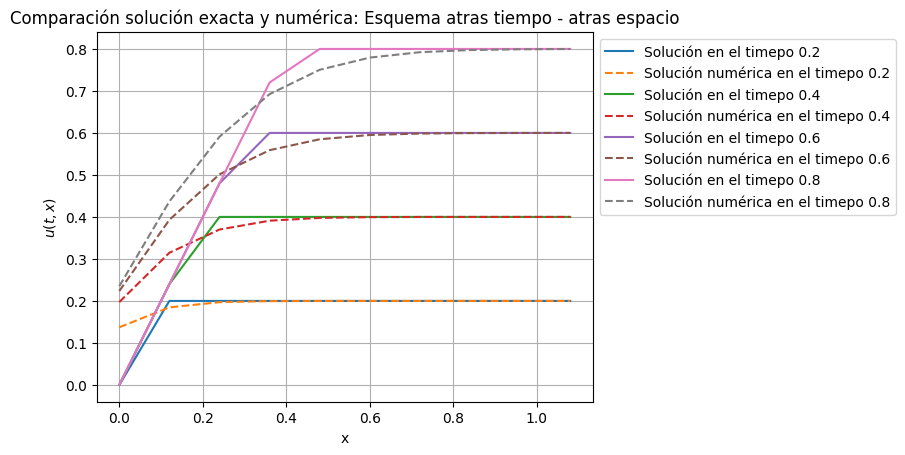

In [17]:
solucion_DF = esquema_AA.calcular_esquema()

indices = [np.where(variable_temporal == t)[0][0] for t in t_comparación]


for pos, t in enumerate(t_comparación):
    u = solucion_exacta(variable_espacial, t)
    plt.plot(variable_espacial, u, label=f"Solución en el timepo {t}")
    plt.plot(variable_espacial, solucion_DF[indices[pos],:], label=f"Solución numérica en el timepo {t}", linestyle='dashed')

plt.title("Comparación solución exacta y numérica: Esquema atras tiempo - atras espacio")
plt.xlabel("x")
plt.ylabel("$u(t, x)$")
plt.grid(True)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

## f. Atrás en tiempo - centrado en espacio

$ \frac{V_{m}^{n} - V_{m}^{n-1}}{k} + a \frac{V_{m+1}^{n} - V_{m-1}^{n}}{2h} = f_{m}^{n}$

Despejando el tiempo nuevo $t_{n}$ en terminos del viejo tiempo $t_{n-1}$, se obtiene: 

$ V_{m}^{n} + \frac{ka}{2h} V_{m+1}^{n} - \frac{ka}{2h} V_{m-1}^{n}  = kf_{m}^{n} + V_{m}^{n-1}$ con: $m=1,...,M-1$ y $n=1,..,N$

Resolviendo el sistema lineal de ecuaciones, nos damos cuenta que se puede resolver como una sistema matricial: <br>
<center>

$AV^{n} = V^{n-1} + \tilde{\hat{F}}$

</center>

Lo que nos da la matriz $A$ como:

<center>

$
A = \begin{bmatrix}
1              & \frac{ak}{2h}    & 0               & 0                & 0               & 0              \\
-\frac{ak}{2h} & 1               & \frac{ak}{2h}    & 0                & 0               & \vdots         \\
0              & -\frac{ak}{2h}  & 1               & \frac{ak}{2h}     & 0               & \vdots         \\
0              & 0               & -\frac{ak}{2h}  & \ddots           & \ddots          & 0              \\
\vdots         & \vdots          & 0               & \ddots           & \ddots          & \frac{ak}{2h}  \\
0              & 0               & 0               & 0                & -\frac{ak}{2h}  & 1              \\
\end{bmatrix}
$

</center>



<center>

$
\tilde{\hat{F}} = \begin{bmatrix}
kf_m^n + \frac{ak}{2h} u(t,0) \\
kf_m^n \\
kf_m^n \\
kf_m^n \\
\vdots \\
kf_m^n - \frac{ak}{2h} u(t,1.2)
\end{bmatrix}
$

</center>

### Estabilidad 

Realizando el análisis de estabilidad con Von-Neumann nos damos cuenta que este esquema es incondicionalmente estable

Demostración: 

Realizando el cambio de $V_{m}^{n}$ por $g^{n} e^{im\theta}$:

$ \Longrightarrow g^{n} e^{im\theta} - g^{n-1} e^{im\theta} + \frac{a\lambda}{2}(g^{n} e^{i(m+1)\theta} - g^{n} e^{i(m-1)\theta}) = 0$

$ \Longrightarrow g^{n} e^{im\theta} [1 - g^{-1} + \frac{a\lambda}{2}( e^{i\theta} - e^{-i\theta})] = 0$

$ \Longrightarrow g^{n} e^{im\theta} [1 - g^{-1} + \frac{a\lambda}{2}(2i\sin \theta)]= 0$

$ \Longrightarrow g^{n} e^{im\theta} [1 - g^{-1} + a\lambda i\sin \theta]= 0$

Despejando $g$:

$ \Longrightarrow 1 - g^{-1} + a\lambda i\sin \theta = 0$

$ \Longrightarrow g = \frac{1}{1 + a\lambda i\sin \theta} $

Sacando $|g|^{2}$ obtenemos que:

$ \Longrightarrow |g|^2 =\frac{1}{1 + (a\lambda)^2 \sin^2 \theta}   $

Se debe de cumplir que $|g|^{2} \leq 1$:

$ \Longrightarrow \frac{1}{1 + (a\lambda)^2 \sin^2 \theta}  \leq 1 $

$ \Longrightarrow 1 + (a\lambda)^2 \sin^2 \theta  \geq 1 $

Como $ 0 \leq \sin^2 \theta \leq 1$ y $ (a\lambda)^2 > 0 $, el esquema va a ser incondicionalmente estable.

In [18]:
# Definición de la constante 
cons_AC = (alpha * k) / (2*h)

In [19]:
class EsquemaAtrasCentrado(Esquema):
    def __init__(
            self,
            valor_M,
            valor_N,
            valor_k,
            constante_matriz,
    ):
        self.valor_M = valor_M
        self.valor_N = valor_N
        self.valor_k = valor_k
        self.constante_matriz = constante_matriz
        
    def calcular_esquema(self):
        diag = np.ones(self.valor_M)
        diag_inf = np.zeros(self.valor_M - 1) - self.constante_matriz
        diag_sup = np.zeros(self.valor_M - 1) + self.constante_matriz

        # Factorización de la matriz
        diag_L, diag_inf_L, diag_sup_U = matrix_factorization_nxn(
            diagonal=diag, 
            diagonal_superior=diag_sup,
            diagonal_inferior=diag_inf
        )

        V = np.zeros((self.valor_N + 1,self.valor_M))

        # Condiciones iniciales 
        cond_iniciales = condicion_inicial(x=variable_espacial, t=variable_temporal[0])
        V[0,:] = cond_iniciales
        for t in range(0, N):
            # Construcción del vector F 
            F = funcion_heterogenea(
                x=variable_espacial, 
                t=variable_temporal[t]
            ) * self.valor_k

            # Definición de la condición de frontera inferior
            condicion_frontera_inf = 0
            # Definición de la condición de frontera superior
            condicion_frontera_sup = variable_temporal[t]

            # Adición del valor en la frontera
            F[0] = F[0] + self.constante_matriz * condicion_frontera_inf
            F[-1] = F[-1] - self.constante_matriz * condicion_frontera_sup
   
            # Valores anteriores
            V_anterior = V[t,:]

            # Aplicación de la sustitución regresiva
            z = sustitucion_regresiva(u_diagonal_superior=diag_sup_U, termino_independiente=V_anterior)

            # Aplicación de la sustitución progresiva
            V[t+1,:] = sustitucion_progresiva(
                l_diagonal= diag_L,
                l_diagonal_inferior=diag_inf_L,
                termino_independiente= z
            ) + F
        
        return V

In [20]:
esquema_AC = EsquemaAtrasCentrado(
    valor_M= M,
    valor_N= N,
    valor_k= k,
    constante_matriz= cons_AC,
)

animar_esquema(
    N= N,
    esquema= esquema_AC,
    condicion_inicial= cond_iniciales,
    filename="Esquema atras tiempo - centrado espacio"
)

✅ Animación guardada en Esquema atras tiempo - centrado espacio


### Comparación solución exacta

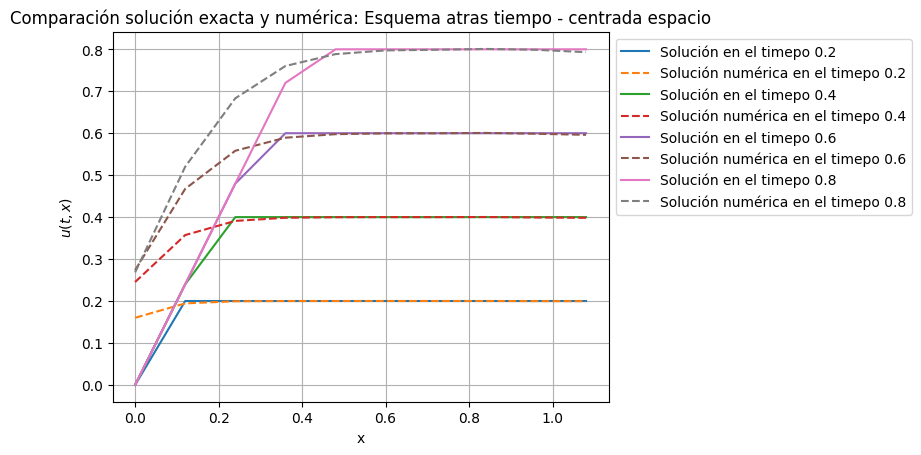

In [21]:
solucion_DF = esquema_AC.calcular_esquema()

indices = [np.where(variable_temporal == t)[0][0] for t in t_comparación]

for pos, t in enumerate(t_comparación):
    u = solucion_exacta(variable_espacial, t)
    plt.plot(variable_espacial, u, label=f"Solución en el timepo {t}")
    plt.plot(variable_espacial, solucion_DF[indices[pos],:], label=f"Solución numérica en el timepo {t}", linestyle='dashed')

plt.title("Comparación solución exacta y numérica: Esquema atras tiempo - centrada espacio")
plt.xlabel("x")
plt.ylabel("$u(t, x)$")
plt.grid(True)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

# Ejercicio 2.

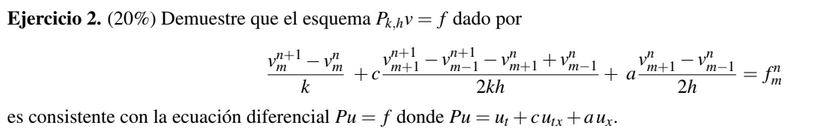

Tenemos que el esquema es consistente si para cualquier función $\varphi(t,x)$ "suave" se cumple que: 

<center>

$P\varphi - P_{kh}\varphi \longrightarrow 0$ cuando $h,k \longrightarrow 0$

</center>

Esto es:

<center>

$(P\varphi)_m^n - P_{kh}\varphi_m^n \longrightarrow 0$ cuando $h,k \longrightarrow 0$

</center>


Tenemos que:

<center>

$(\varphi_t)_m^n + c(\varphi_{tx})_m^n + a (\varphi_x)_m^n - [\frac{\varphi_{m}^{n+1} - \varphi_{m}^{n}}{k} + c\frac{\varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1} - \varphi_{m+1}^{n} + \varphi_{m-1}^{n}}{2kh} + a \frac{\varphi_{m+1}^{n} - \varphi_{m-1}^{n}}{2h}]$

</center>

Para la derivada temporal:

<center>

$\varphi_{m}^{n+1} = \varphi_{m}^{n} + k (\varphi_{t})_{m}^{n} + \frac{k^2}{2} (\varphi_{tt})_{m}^{n} + O(k^3)$

</center>

<center>

$ \Longrightarrow \varphi_{m}^{n+1} - \varphi_{m}^{n} = k (\varphi_{t})_{m}^{n} + \frac{k^2}{2} (\varphi_{tt})_{m}^{n} + O(k^3)$

</center>


<center>

$ \Longrightarrow \frac{\varphi_{m}^{n+1} - \varphi_{m}^{n}}{k} = (\varphi_{t})_{m}^{n} + \frac{k}{2} (\varphi_{tt})_{m}^{n} + O(k^2)$

$\therefore  (\varphi_{t})_{m}^{n} - \frac{\varphi_{m}^{n+1} - \varphi_{m}^{n}}{k} =\frac{k}{2} (\varphi_{tt})_{m}^{n} + O(k^2)$

</center>

Para la derivada espacial:

<center>

$\varphi_{m \pm 1}^{n} = \varphi_{m}^{n} \pm h (\varphi_{x})_{m}^{n} + \frac{h^2}{2} (\varphi_{xx})_{m}^{n} \pm \frac{h^3}{3!} (\varphi_{xxx})_{m}^{n} + \frac{h^4}{4!} (\varphi_{xxxx})_{m}^{n} + O(h^5)$

</center>

Restando $\varphi_{m + 1}^{n} - \varphi_{m - 1}^{n}$ se obtiene:

<center>

$ \varphi_{m + 1}^{n} - \varphi_{m - 1}^{n} = 2h (\varphi_{x})_{m}^{n} + 2 \frac{h^3}{3!} (\varphi_{xxx})_{m}^{n} + O(h^5) $

</center>


<center>

$ \Longrightarrow \frac{\varphi_{m + 1}^{n} - \varphi_{m - 1}^{n}}{2h} = (\varphi_{x})_{m}^{n} + \frac{h^2}{3!} (\varphi_{xxx})_{m}^{n} + O(h^4)$

$\therefore  (\varphi_{x})_{m}^{n} - \frac{\varphi_{m + 1}^{n} - \varphi_{m - 1}^{n}}{2h} = \frac{h^2}{3!} (\varphi_{xxx})_{m}^{n} + O(h^4)$

</center>

Para la derivada mixta, vamos a ver que sucede con $\varphi_{m+1}^{n+1}$ y $\varphi_{m-1}^{n+1}$:

* $\varphi_{m+1}^{n+1} = \varphi_{m+1}^{n} + k (\varphi_{t})_{m+1}^{n} + \frac{k^2}{2} (\varphi_{tt})_{m+1}^{n} + \frac{k^3}{3!} (\varphi_{ttt})_{m+1}^{n} + O(k^4)$
* $\varphi_{m-1}^{n+1} = \varphi_{m-1}^{n} + k (\varphi_{t})_{m-1}^{n} + \frac{k^2}{2} (\varphi_{tt})_{m-1}^{n} + \frac{k^3}{3!} (\varphi_{ttt})_{m-1}^{n} + O(k^4)$

Restando $\varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1}$ se obtiene: 

<center>

$\varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1} = \varphi_{m+1}^{n} - \varphi_{m-1}^{n} + k [(\varphi_{t})_{m+1}^{n} - (\varphi_{t})_{m-1}^{n}] + \frac{k^2}{2} [(\varphi_{tt})_{m+1}^{n} - (\varphi_{tt})_{m-1}^{n}] + \frac{k^3}{3!} [(\varphi_{ttt})_{m+1}^{n} - (\varphi_{ttt})_{m-1}^{n}] + O(k^4)$

$\Longrightarrow \varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1} - \varphi_{m+1}^{n} + \varphi_{m-1}^{n} = k [(\varphi_{t})_{m+1}^{n} - (\varphi_{t})_{m-1}^{n}] + \frac{k^2}{2} [(\varphi_{tt})_{m+1}^{n} - (\varphi_{tt})_{m-1}^{n}] + \frac{k^3}{3!} [(\varphi_{ttt})_{m+1}^{n} - (\varphi_{ttt})_{m-1}^{n}] + O(k^4)$

</center>

Al observar las derivadas $(\varphi_{t})_{m \pm 1}^{n}$:

* $(\varphi_{t})_{m \pm 1}^{n} = (\varphi_{t})_{m}^{n} \pm h ((\varphi_{tx}))_{m}^{n} + \frac{h^2}{2} (\varphi_{txx})_{m}^{n} \pm \frac{h^3}{3!} (\varphi_{txxx})_{m}^{n} + O(h^4)$


Restando $(\varphi_{t})_{m + 1}^{n} - (\varphi_{t})_{m - 1}^{n}$:

<center>

$(\varphi_{t})_{m + 1}^{n} - (\varphi_{t})_{m - 1}^{n} = 2h (\varphi_{tx})_{m}^{n} + 2\frac{h^3}{3!} (\varphi_{txxx})_{m}^{n} + O(h^5)$

$\Longrightarrow (\varphi_{t})_{m + 1}^{n} - (\varphi_{t})_{m - 1}^{n} = 2h [(\varphi_{tx})_{m}^{n} + \frac{h^2}{3!} (\varphi_{txxx})_{m}^{n} + O(h^4)]$

</center>

Sustituyendo $(\varphi_{t})_{m + 1}^{n} - (\varphi_{t})_{m - 1}^{n}$ en $\varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1} - \varphi_{m+1}^{n} + \varphi_{m-1}^{n}$, se obtiene: 

<center>

$\varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1} - \varphi_{m+1}^{n} + \varphi_{m-1}^{n} = 2hk [(\varphi_{tx})_{m}^{n} + \frac{h^2}{3!} (\varphi_{txxx})_{m}^{n} + O(h^4)] + \frac{k^2}{2} [(\varphi_{tt})_{m+1}^{n} - (\varphi_{tt})_{m-1}^{n}] + \frac{k^3}{3!} [(\varphi_{ttt})_{m+1}^{n} - (\varphi_{ttt})_{m-1}^{n}] + O(k^4)$

</center>

Dividiendo por $2hk$:

$\Longrightarrow \frac{\varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1} - \varphi_{m+1}^{n} + \varphi_{m-1}^{n}}{2hk} = (\varphi_{tx})_{m}^{n} + \frac{h^2}{3!} (\varphi_{txxx})_{m}^{n} + \frac{k^2}{4hk} [(\varphi_{tt})_{m+1}^{n} - (\varphi_{tt})_{m-1}^{n}] + \frac{k^3}{3!*2hk} [(\varphi_{ttt})_{m+1}^{n} - (\varphi_{ttt})_{m-1}^{n}] + \frac{O(k^4)}{2hk} + O(h^4)$

$\Longrightarrow \frac{\varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1} - \varphi_{m+1}^{n} + \varphi_{m-1}^{n}}{2hk} = (\varphi_{tx})_{m}^{n} + \frac{h^2}{3!} (\varphi_{txxx})_{m}^{n} + \frac{k}{4h} [(\varphi_{tt})_{m+1}^{n} - (\varphi_{tt})_{m-1}^{n}] + \frac{k^2}{3!*2h} [(\varphi_{ttt})_{m+1}^{n} - (\varphi_{ttt})_{m-1}^{n}] + \frac{O(k^3)}{2h} + O(h^4)$

$\therefore (\varphi_{tx})_{m}^{n} - \frac{\varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1} - \varphi_{m+1}^{n} + \varphi_{m-1}^{n}}{2hk} =  \frac{h^2}{3!} (\varphi_{txxx})_{m}^{n} + \frac{k}{4h} [(\varphi_{tt})_{m+1}^{n} - (\varphi_{tt})_{m-1}^{n}] + \frac{O(k^2)}{2h} + O(h^4)$

Vemos que:

$(P\varphi)_m^n - P_{kh}\varphi_m^n$


$\Longrightarrow [(\varphi_t)_m^n - (\frac{\varphi_{m}^{n+1} - \varphi_{m}^{n}}{k})]  + c[(\varphi_{tx})_m^n - (\frac{\varphi_{m+1}^{n+1} - \varphi_{m-1}^{n+1} - \varphi_{m+1}^{n} + \varphi_{m-1}^{n}}{2kh})] + a [(\varphi_x)_m^n - (\frac{\varphi_{m+1}^{n} - \varphi_{m-1}^{n}}{2h})]$

Lo que nos queda:

<center>

$\Longrightarrow \frac{k}{2} (\varphi_{tt})_{m}^{n} + O(k^2) + c (\frac{h^2}{3!} (\varphi_{txxx})_{m}^{n} + \frac{k}{4h} [(\varphi_{tt})_{m+1}^{n} - (\varphi_{tt})_{m-1}^{n}] + \frac{O(k^2)}{2h} + O(h^4))+ a(\frac{h^2}{3!} (\varphi_{xxx})_{m}^{n} + O(h^4))$

$\Longrightarrow \frac{k}{2} (\varphi_{tt})_{m}^{n} +  \frac{ch^2}{3!} (\varphi_{txxx})_{m}^{n} + \frac{ck}{4h} [(\varphi_{tt})_{m+1}^{n} - (\varphi_{tt})_{m-1}^{n}] + \frac{ah^2}{3!} (\varphi_{xxx})_{m}^{n} + O(h^4) + \frac{O(k^2)}{2h}$


</center>


Vemos que si el $lim_{h,k \rightarrow 0} \frac{k}{h} = 0$ entonces el esquema es consistente

# Ejercico 3.

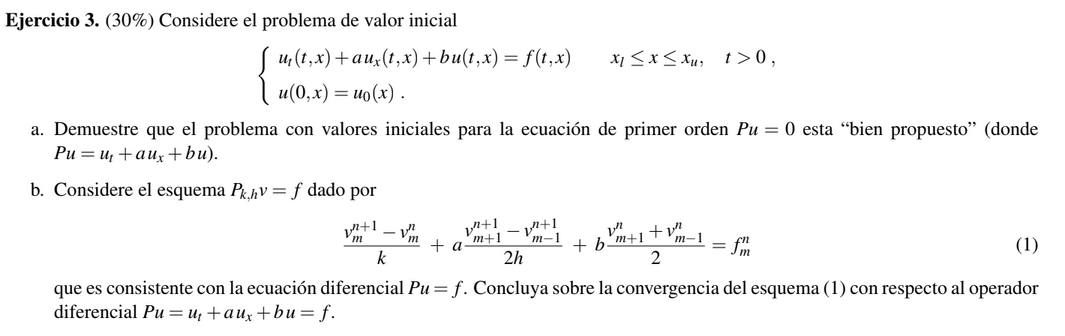

### a.

Si un problema de valores iniciales está "bien puesto", este debe de cumplir que: 

<center> 

$\forall T > 0 ; \exists C_T > 0$ tal que

$\int_{-\infty}^{\infty} |u(t,x)|^2 dx \leq C_T \int_{-\infty}^{\infty} |u(0,x)|^2 dx$ $\forall 0 \leq t \leq T$

</center>

Tenemos que la solución para la E.D.P de primer orden para $Pu=0$ donde $Pu = u_t + a u_x + bu$ está dada por: 

<center>

$u(t,x) = u_0(x-at) e^{-bt} + \int_{0}^{t} f(s, x-a(t-s)) e^{-b(t-s)} ds$

</center>

Si $u_0$ y $f$ son funciones continuas y acotadas la solución $u(t,x)$ es continua en $(t,x)$ y diferenciable en $t$ y $x$, por lo tanto la solución existe. Sustituyendo la solución $u(t,x)$ obtenemos que:

<center>

$\int_{-\infty}^{\infty} |u(t,x)|^2 dx = \int_{-\infty}^{\infty} |u_0(x-at) e^{-bt} + \int_{0}^{t} f(s, x-a(t-s)) e^{-b(t-s)} ds|^2 dx$

</center>

Tenemos que $|a + b|^2 \leq |a|^2 + |b|^2$, con lo que:

<center>

$\int_{-\infty}^{\infty} |u(t,x)|^2 dx \leq \int_{-\infty}^{\infty} |u_0(x-at) e^{-bt}|^2 dx + \int_{-\infty}^{\infty} |\int_{0}^{t} f(s, x-a(t-s)) e^{-b(t-s)} ds|^2 dx$

</center>

Como $f(t,x) = 0$, tenemos que:

<center>

$\int_{-\infty}^{\infty} |u(t,x)|^2 dx \leq \int_{-\infty}^{\infty} |u_0(x-at) e^{-bt}|^2 dx \\
= e^{-2bt} \int_{-\infty}^{\infty} |u_0(x-at)|^2 dx$

</center>

Haciendo el cambio de variable $\xi = x - at$, tenemos que $d\xi = dx$. Y los limetes de integración no cambian, obtenemos que: 

<center>

$\int_{-\infty}^{\infty} |u(t,x)|^2 dx \leq e^{-2bt} \int_{-\infty}^{\infty} |u_0(\xi)|^2 d\xi = e^{-2bt} \int_{-\infty}^{\infty} |u_0(x)|^2 dx$

</center>

Con $C_T = e^{-2bt}$ la cual es una constante que no diverge para valores de $t > 0$ y $b>0$, también el valor de la constante $C_T$ va a ser  $\leq 0$.

### b.

Aplicando el siguiente corolario: 

* Si un esquema de diferencias finitas (D.F) de **un paso** con coeficientes constantes se modifica y la modificación genera un factor de amplificación con unico cambio $O(k)$ $\forall \xi$, entonces el esquema original es estable si solo si el esquema original lo es.

Si vemos el esquema propuesto vemos que el factor de amplificación se modifica por un $O(k)$:

<center>

$\frac{g^{n+1} e^{im\theta} - g^n e^{im\theta}}{k} + \frac{a}{2h} (g^{n+1} e^{i(m+1)\theta} - g^{n+1} e^{i(m-1)\theta}) + \frac{b}{2} (g^n e^{i(m+1)\theta} - g^n e^{i(m-1)\theta}) = 0$

</center>

Organizando el factor de amplificación y despejando $g^{n} e^{im\theta}$:

<center>

$g (1 + ia\lambda \sin \theta) - 1 + bk\cos \theta = 0 $

</center>


Tenemos que si el esquema: 

<center>

$(*)$ $\frac{V_{m}^{n+1} - V_{m}^{n}}{k} + \frac{a}{2h} (V_{m+1}^{n+1} - V_{m-1}^{n+1})$

</center>

Es estable nuestro esquema tambien va a ser estable. Encontrando el factor de amplificación de $(*)$

<center>

$\Longrightarrow \frac{g^{n+1} e^{im\theta} - g^n e^{im\theta}}{k} + \frac{a}{2h} (g^{n+1} e^{i(m+1)\theta} - g^{n+1} e^{i(m-1)\theta}) = 0$

</center>

<center>

$\Longrightarrow g^{n} e^{im\theta}[ g - 1 \frac{a\lambda}{2} g (e^{i\theta} - e^{-i\theta})] = 0$

$\Longrightarrow g^{n} e^{im\theta}[ g - 1 \frac{a\lambda}{2} g (2i\sin \theta)] = 0$

</center>

Lo que nos da: 

<center>

$\Longrightarrow g - 1 \frac{a\lambda}{2} g (2i\sin \theta) = 0$

$\Longrightarrow g(1 + a\lambda i\sin \theta)- 1  = 0$

$\Longrightarrow g(1 + a\lambda i\sin \theta)- 1  = 0$

$\Longrightarrow g = \frac{1}{1 + a\lambda i\sin \theta}$

$\Longrightarrow |g|^2 = \frac{1}{|1 + a\lambda i\sin \theta|^2}$

$\Longrightarrow |g|^2 = \frac{1}{1 + (a\lambda)^2 \sin^2 \theta}$

</center>

Se debe de cumplir que $|g|^2 \leq 1$ y como $ 0 \leq \sin^2 \theta \leq 1$ y $(a \lambda)^2$ siempre va a ser un numero positivo, tenemos que el factor de amplificación del esquema $(*)$ va a ser menor o igual a uno. Dando como resultado que el esquema $(*)$ siempre va a ser estable. En consecuencia nuestro esquema va a ser estable.

Analisando la consistencia del esquema vemos que:

* $(\varphi_t)_{m}^{n} - \frac{(\varphi)_{m}^{n+1} - (\varphi)_{m}^{n}}{k} = \frac{k}{2} (\varphi_{tt})_{m}^{n} +  O(k^2)$

* $(\varphi_x)_{m}^{n} - \frac{(\varphi)_{m+1}^{n+1} - (\varphi)_{m-1}^{n+1}}{2h} = k(\varphi_{xt})_m^n + \frac{k^2}{2}(\varphi_{xtt})_m^n + \frac{h^2}{3!}(\varphi_{xxx})_m^{n+1} + O(h^4) + O(k^3)$

* $(\varphi)_m^n - \frac{(\varphi)_{m+1}^{n} + (\varphi)_{m-1}^{n}}{2} = \frac{h^2}{2} (\varphi_{xx})_m^n   + O(h^3) $


De lo anterior podemos ver que para cualquier función "suave" $\varphi(t,x)$ se cumple:

<center>

$(P\varphi)_m^n - P_{kh}\varphi_m^n \longrightarrow 0 $ cuando $h,k \longrightarrow 0$

</center>

Por lo tanto el esquema propuesto es consistente.

Como el problema de valores iniciales está "bien puesto" y el esquema propuesto es consitente y estable se puede concluir por teorema que el esquema es convergente.